In [1]:
import pandas as pd
import seaborn as sns 
import plotly.express as px
import numpy as np


In [2]:
df_patients_clinique = pd.read_csv("/data/data_cleaned/patients_FR_geocoded_adulte_clinique.csv",sep=";", dtype= {"pseudo_provisoire":int, "codepost": str})

# df_cim = pd.read_excel("../data/data_octobre_2023/CODECIM_updated.csv.xlsx")
# df_cim.drop('Unnamed: 3', axis=1, inplace=True)

# correspondance = df_cim.set_index('topo_initiale_cim10')['Proposition_Clémence_1'].to_dict()

# df_patients_clinique['pathologie'] = df_patients_clinique['topo_initiale_cim10'].map(correspondance)

FileNotFoundError: [Errno 2] No such file or directory: '../data/data_cleaned/patients_FR_geocoded_adulte_clinique.csv'

In [ ]:
pathologies = df_patients_clinique.patho.unique().tolist()
del(pathologies[-1])

## Medical event 
df_ap = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023//medical_event/aplasie.xlsx", dtype= {"pseudo_provisoire":int})
df_ep = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/ep.xlsx", dtype= {"pseudo_provisoire":int})
df_ins = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/ins_surrenale.xlsx", dtype= {"pseudo_provisoire":int})
df_ira = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/ira.xlsx", dtype= {"pseudo_provisoire":int})
df_mtev = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/mtev.xlsx", dtype= {"pseudo_provisoire":int})
df_pneumo = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/pneumopathie.xlsx",dtype= {"pseudo_provisoire":int})

df_mtev_ep = pd.concat([df_ep,df_mtev])
dict_em = {
    "ap" : df_ap,
    "ep_mtev" : df_mtev_ep,
    "ins" : df_ins,
    "ira" : df_ira, 
    "pneumo" : df_pneumo
}
evenement = ["ap", "ep_mtev","ins", "ira","pneumo"]
id_all_patients = set(df_patients_clinique["pseudo_provisoire"].unique())

for nom_df in dict_em : 
    df = dict_em[nom_df]
    df_no_duplicates = df.drop_duplicates(subset="pseudo_provisoire", keep="first")
    df_no_duplicates = df_no_duplicates.rename({"Date début hospitalisation": f'date_debut_hospitalisation_{nom_df}',
                                                'Date fin hospitalisation': f'date_fin_hospitalisation_{nom_df}'}, axis=1)
    print(f"taille initiale :{len(df_no_duplicates)}")
    df_suivis = df_no_duplicates[df_no_duplicates["pseudo_provisoire"].isin(id_all_patients)]
    print(f"taille finale :{len(df_suivis)}")

    df_suivis.loc[:,'EM'] = nom_df
    dict_em[nom_df] = df_suivis

taille initiale :654
taille finale :483
taille initiale :493
taille finale :465
taille initiale :25
taille finale :24
taille initiale :351
taille finale :334
taille initiale :467
taille finale :441


C:\Users\lpokambo\AppData\Local\Temp\ipykernel_27500\1751316380.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suivis.loc[:,'EM'] = nom_df
C:\Users\lpokambo\AppData\Local\Temp\ipykernel_27500\1751316380.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suivis.loc[:,'EM'] = nom_df
C:\Users\lpokambo\AppData\Local\Temp\ipykernel_27500\1751316380.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

## Analyse univariée 

In [ ]:
df_evenement = pd.concat(dict_em, ignore_index=True)
# len(df_evenement)
df_evenement.columns

Index(['pseudo_provisoire', 'date_debut_hospitalisation_ap',
       'date_fin_hospitalisation_ap', 'EM',
       'date_debut_hospitalisation_ep_mtev',
       'date_fin_hospitalisation_ep_mtev', 'date_debut_hospitalisation_ins',
       'date_fin_hospitalisation_ins', 'date_debut_hospitalisation_ira',
       'date_fin_hospitalisation_ira', 'date_debut_hospitalisation_pneumo',
       'date_fin_hospitalisation_pneumo'],
      dtype='object')

In [ ]:
# df_evenement_test = df_evenement.drop_duplicates(subset="pseudo_provisoire", keep="first")
# len(df_evenement_test)

multiplicité 0-n : plusieurs fois l'identifiant dans la table 

In [ ]:
col_to_keep= ['pseudo_provisoire','geometry','patient_sexe','date_naissance','ageaudiag','patho']
df_pat_clinique = df_patients_clinique[col_to_keep]

data_clinique_em = pd.merge(df_pat_clinique,df_evenement, how="left", left_on=df_pat_clinique['pseudo_provisoire'], right_on=df_evenement['pseudo_provisoire'],validate="1:m")

In [ ]:
for ev in evenement: 
    data_clinique_em[f'presence_evenement_{ev}'] = "non"

data_clinique_em["presence_evenement"] = "non"


for i in data_clinique_em.index: 
    if pd.isna(data_clinique_em.at[i,"EM"]) is False : 
        ev = data_clinique_em.at[i,"EM"]
        data_clinique_em.at[i,f'presence_evenement_{ev}'] = "oui"
        data_clinique_em.at[i,"presence_evenement"] = "oui"


In [ ]:
data_clinique_em.to_csv("data_clinique_em.csv", sep=";")

In [ ]:
# Création d'un DataFrame vide pour les résultats
result_df = pd.DataFrame(index=pd.unique(data_clinique_em['patho']))

# Pour chaque événement, compter les 'oui' et 'non' pour chaque pathologie
col_presence = ['presence_evenement_ap','presence_evenement_ep_mtev', 'presence_evenement_ins','presence_evenement_ira', 'presence_evenement_pneumo']
for col in col_presence:
    counts = data_clinique_em.groupby(['patho', col]).size().unstack(fill_value=0)
    counts.columns = [f"{col}_{status}" for status in counts.columns]
    result_df = result_df.join(counts, how='left')

# Réinitialiser l'index pour inclure la pathologie comme colonne
result_df.reset_index(inplace=True)
result_df.rename(columns={'index': 'pathologie'}, inplace=True)

# Vérification du résultat
result_df.to_csv("EM_par_pathologie.csv",sep=";")


// Mise en forme du tableau => analyse univarié : Chi-2 

In [ ]:

result_df["presence_ev"] = result_df['presence_evenement_ap_oui'] + result_df['presence_evenement_ep_mtev_oui'] + result_df['presence_evenement_ins_oui']+  result_df['presence_evenement_ira_oui']+ result_df['presence_evenement_pneumo_oui']
result_df["absence_ev"] = result_df['presence_evenement_ap_non'] + result_df['presence_evenement_ep_mtev_non'] + result_df['presence_evenement_ins_non']+  result_df['presence_evenement_ira_non']+ result_df['presence_evenement_pneumo_non']

res_all = result_df[["pathologie","presence_ev","absence_ev"]]

res_all

,pathologie,presence_ev,absence_ev
0,Hemato,308.0,10642.0
1,Ophtalmo,5.0,20875.0
2,Uro,53.0,26567.0
3,ORL,99.0,7316.0
4,Sein,524.0,173036.0
5,Gastro,193.0,9537.0
6,Gynéco,142.0,11758.0
7,Sarcome,93.0,7277.0
8,Dermato,5.0,5030.0
9,Thorax,290.0,8895.0


In [ ]:
contigency = pd.crosstab(data_clinique_em['patho'], data_clinique_em['presence_evenement'])
contigency

presence_evenement,non,oui
patho,,
Autre,176,6
Dermato,1002,5
Endocrino,914,13
Gastro,1753,193
Gynéco,2238,142
Hemato,1882,308
Neuro,532,15
ORL,1384,99
Ophtalmo,4171,5


In [ ]:
from scipy.stats import chi2_contingency as chi2_contingency

test_result = chi2_contingency(contigency)

test_result
#khi2, pval , ddl , contingent_theorique = chi2_contingency(matrice)

Chi2ContingencyResult(statistic=2956.4687972210854, pvalue=0.0, dof=12, expected_freq=array([[1.76538592e+02, 5.46140758e+00],
       [9.76782212e+02, 3.02177881e+01],
       [8.99182831e+02, 2.78171694e+01],
       [1.88760495e+03, 5.83950503e+01],
       [2.30858159e+03, 7.14184068e+01],
       [2.12428306e+03, 6.57169374e+01],
       [5.30585770e+02, 1.64142305e+01],
       [1.43849853e+03, 4.45014695e+01],
       [4.05068770e+03, 1.25312297e+02],
       [1.42976860e+03, 4.42313998e+01],
       [3.36703715e+04, 1.04162846e+03],
       [1.78187579e+03, 5.51242073e+01],
       [5.16423882e+03, 1.59761176e+02]]))

In [ ]:
#data_fusionnee.columns

col_to_keep = ["pseudo_provisoire",'DISP_MED20', 'quartile_revenu','P20_taux_CHOM1564', 'quartile_chomage',
       'pathologie','EM',]

In [ ]:
df_patients_clinique_rev_chom = pd.read_csv('/data/data_cleaned/patients_FR_revenus_chomage.csv',sep=";")

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_27500\1592917697.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_patients_clinique_rev_chom = pd.read_csv('../data/data_cleaned/patients_FR_revenus_chomage.csv',sep=";")


In [ ]:
fig = px.histogram(df_patients_clinique_rev_chom, x="DISP_MED20", color="patho", opacity=0.75)
fig.show()

In [ ]:
for patho in pathologies : 
    df_patho = df_patients_clinique_rev_chom[df_patients_clinique_rev_chom["patho"]==patho]
    id_patho = df_patho["pseudo_provisoire"].unique()



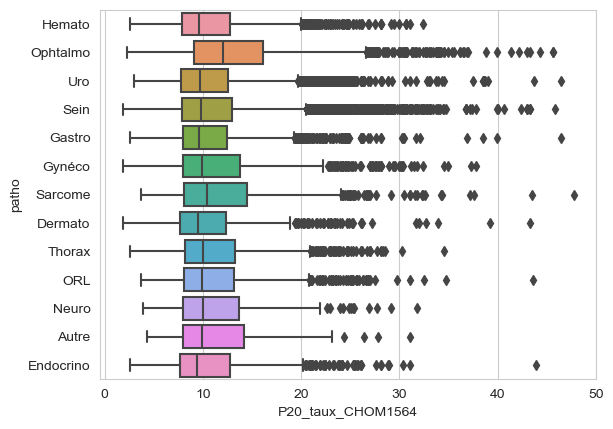

In [ ]:
sns.set_style("whitegrid")


box_plot = sns.boxplot(x= "P20_taux_CHOM1564", y ="patho",data=df_patients_clinique_rev_chom)
# box_plot.set(title=f"Distribution des occurences par patients d'evenements médicaux pour la pathologie :{patho}")

# box_plot.figure.tight_layout()
